## Merge individual datasets

Load Tagesschau first due to different date format

In [ ]:
# import sys
# from pathlib import Path

# import numpy as np
# import pandas as pd
# import plotly.graph_objects as go


# def resolve_project_root() -> Path:
#     cwd = Path.cwd().resolve()
#     for candidate in (cwd, cwd.parent, *cwd.parents):
#         if (candidate / "data preprocessing").exists():
#             return candidate
#     raise FileNotFoundError("Could not locate project root containing data preprocessing")


# def find_clean_csv(project_root: Path, filename: str) -> Path:
#     candidates = [
#         project_root / "data preprocessing" / filename,
#         project_root / filename,
#         project_root / "data" / "raw" / filename,
#     ]
#     for path in candidates:
#         if path.exists():
#             return path
#     raise FileNotFoundError(f"Missing cleaned file: {filename}")


# PROJECT_ROOT = resolve_project_root()
# if str(PROJECT_ROOT) not in sys.path:
#     sys.path.insert(0, str(PROJECT_ROOT))

# ts_path = find_clean_csv(PROJECT_ROOT, "tagesschau_clean.csv")
# df_ts = pd.read_csv(ts_path)
# print(f"tagesschau   {df_ts.shape} <- {ts_path}")

# # Parse date column to a consistent datetime64[ns] calendar date
# df_ts["Date"] = (
#     pd.to_datetime(df_ts["Date"], errors="coerce", utc=True)
#       .dt.tz_convert("Europe/Berlin")
#       .dt.tz_localize(None)
#       .dt.normalize()
# )

# print(df_ts["Date"].dtype)
# df_ts.head()

tagesschau   (6320, 4) <- /Users/katinkakurz/projects/Thesis/data preprocessing/tagesschau_clean.csv
datetime64[us]


,Date,Title,Text,source
0,2025-09-01,Deutschland holt zehn afghanische Familien aus...,Zehn afghanische Familien dürfen aus Pakistan ...,Tagesschau
1,2025-10-01,Afghanistan ist wieder online,Handys und Internet funktionieren in Afghanist...,Tagesschau
2,2025-10-24,Äthiopien suspendiert Deutsche-Welle-Journalisten,Die Deutsche Welle darf vorerst nicht mehr dir...,Tagesschau
3,2025-10-02,Mindestens 30 Tote bei Einsturz von Baugerüst,Viele Menschen befanden sich in der Kirche der...,Tagesschau
4,2025-09-30,Brechen afrikanische Exporte in die USA ein?,Seit Jahrzehnten verkaufen mehr als die Hälfte...,Tagesschau


In [ ]:
# # Format Date as DD-MM-YYYY (no time)
# df_ts["Date"] = pd.to_datetime(df_ts["Date"], errors="coerce").dt.strftime("%d-%m-%Y")

# df_ts[["Date"]].head()

,Date
0,01-09-2025
1,01-10-2025
2,24-10-2025
3,02-10-2025
4,30-09-2025


In [ ]:
# # Convert Date from string format (DD-MM-YYYY) to datetime64[ns]
# df_ts["Date"] = pd.to_datetime(df_ts["Date"], format="%d-%m-%Y", errors="coerce")

# df_ts[["Date"]].dtypes

Date    datetime64[us]
dtype: object

load all other outlets

In [ ]:
# import sys
# from pathlib import Path

# import numpy as np
# import pandas as pd
# import plotly.graph_objects as go


# def resolve_project_root() -> Path:
#     cwd = Path.cwd().resolve()
#     for candidate in (cwd, cwd.parent, *cwd.parents):
#         if (candidate / "data preprocessing").exists():
#             return candidate
#     raise FileNotFoundError("Could not locate project root containing data preprocessing")


# def find_clean_csv(project_root: Path, filename: str) -> Path:
#     candidates = [
#         project_root / "data preprocessing" / filename,
#         project_root / filename,
#         project_root / "data" / "raw" / filename,
#     ]
#     for path in candidates:
#         if path.exists():
#             return path
#     raise FileNotFoundError(f"Missing cleaned file: {filename}")


# PROJECT_ROOT = resolve_project_root()
# if str(PROJECT_ROOT) not in sys.path:
#     sys.path.insert(0, str(PROJECT_ROOT))

# file_map = {
#     "antispiegel": "antispiegel_clean.csv",
#     "compact": "compact_clean.csv",
#     "nius": "nius_clean.csv",
#     "rt_de": "rt_de_clean.csv",
#     "tichys": "tichys_clean.csv",
#     "dkurier": "dkurier_clean.csv",
# }

# required_columns = ["Date", "Title", "Text", "source"]
# datasets = {}
# for name, filename in file_map.items():
#     path = find_clean_csv(PROJECT_ROOT, filename)
#     frame = pd.read_csv(path)
#     missing_columns = [col for col in required_columns if col not in frame.columns]
#     if missing_columns:
#         raise KeyError(f"{filename} is missing required columns: {missing_columns}")
#     frame = frame[required_columns].copy()
#     parsed_dates = pd.to_datetime(frame["Date"], errors="coerce", utc=True)
#     if name == "tagesschau":
#         parsed_dates = parsed_dates.dt.tz_convert("Europe/Berlin")
#     frame["Date"] = parsed_dates.dt.tz_localize(None).dt.normalize()
#     datasets[name] = frame
#     print(f"{name:<12} {frame.shape} <- {path}")

# overall_df = pd.concat(datasets.values(), ignore_index=True)
# print("overall_df  ", overall_df.shape)


antispiegel  (565, 4) <- /Users/katinkakurz/projects/Thesis/data preprocessing/antispiegel_clean.csv
compact      (1486, 4) <- /Users/katinkakurz/projects/Thesis/data preprocessing/compact_clean.csv
nius         (3269, 4) <- /Users/katinkakurz/projects/Thesis/data preprocessing/nius_clean.csv
rt_de        (4560, 4) <- /Users/katinkakurz/projects/Thesis/data preprocessing/rt_de_clean.csv
tichys       (2756, 4) <- /Users/katinkakurz/projects/Thesis/data preprocessing/tichys_clean.csv
dkurier      (1484, 4) <- /Users/katinkakurz/projects/Thesis/data preprocessing/dkurier_clean.csv
overall_df   (14120, 4)


Change dtype of Date to match tagesschau

In [ ]:
# print(overall_df["Date"].dtype)    

datetime64[us]


In [ ]:
# overall_df["Date"] = pd.to_datetime(overall_df["Date"], errors="coerce", utc=True)\
#                         .dt.tz_localize(None)\
#                         .dt.normalize()


In [ ]:
# print(overall_df["Date"].dtype)  

datetime64[us]


merge Tagesschau and rest

In [ ]:
# # Concatenate existing combined dataframe with Tagesschau dataframe
# overall_df = pd.concat([overall_df, df_ts], ignore_index=True)

# # Quick check
# print("overall_df shape:", overall_df.shape)
# overall_df["source"].value_counts()

overall_df shape: (20440, 4)


source
Tagesschau           6320
RT_de                4560
Nius                 3269
Tichys_Einblick      2756
Compact              1486
Deutschlandkurier    1484
Antispiegel           565
Name: count, dtype: int64

In [13]:
# # Convert Date to datetime in the combined dataframe
# overall_df["Date"] = pd.to_datetime(overall_df["Date"], errors="coerce")

# overall_df["Date"].dtype

In [ ]:
# # Add a unique ID column for each row in overall_df
# overall_df = overall_df.reset_index(drop=True)
# overall_df["row_id"] = overall_df.index + 1

# # Optional quick check
# print("Unique IDs:", overall_df["row_id"].is_unique)
# overall_df[["row_id", "Date", "Title"]].head()

Unique IDs: True


,row_id,Date,Title
0,1,2025-08-01,Bereitet der Westen die Entmachtung oder sogar...
1,2,2025-08-01,EU-Kommission hat Textnachrichten zum Kauf der...
2,3,2025-08-01,Wahlkommission rechtfertigt Einmischung der EU...
3,4,2025-08-02,Fordert Russland wirklich die Vernichtung alle...
4,5,2025-08-02,Der Spiegel macht mal wieder Berichterstattung...


## Load Cleaned Combined Dataset

In [1]:
import pandas as pd

overall_df = pd.read_csv("outputs/df_combined.csv")

In [6]:
overall_df['Date'] = pd.to_datetime(overall_df['Date'], errors='coerce')

In [9]:
overall_df['Date'].min(), overall_df['Date'].max()

(Timestamp('2025-08-01 00:00:00'), Timestamp('2026-01-31 00:00:00'))

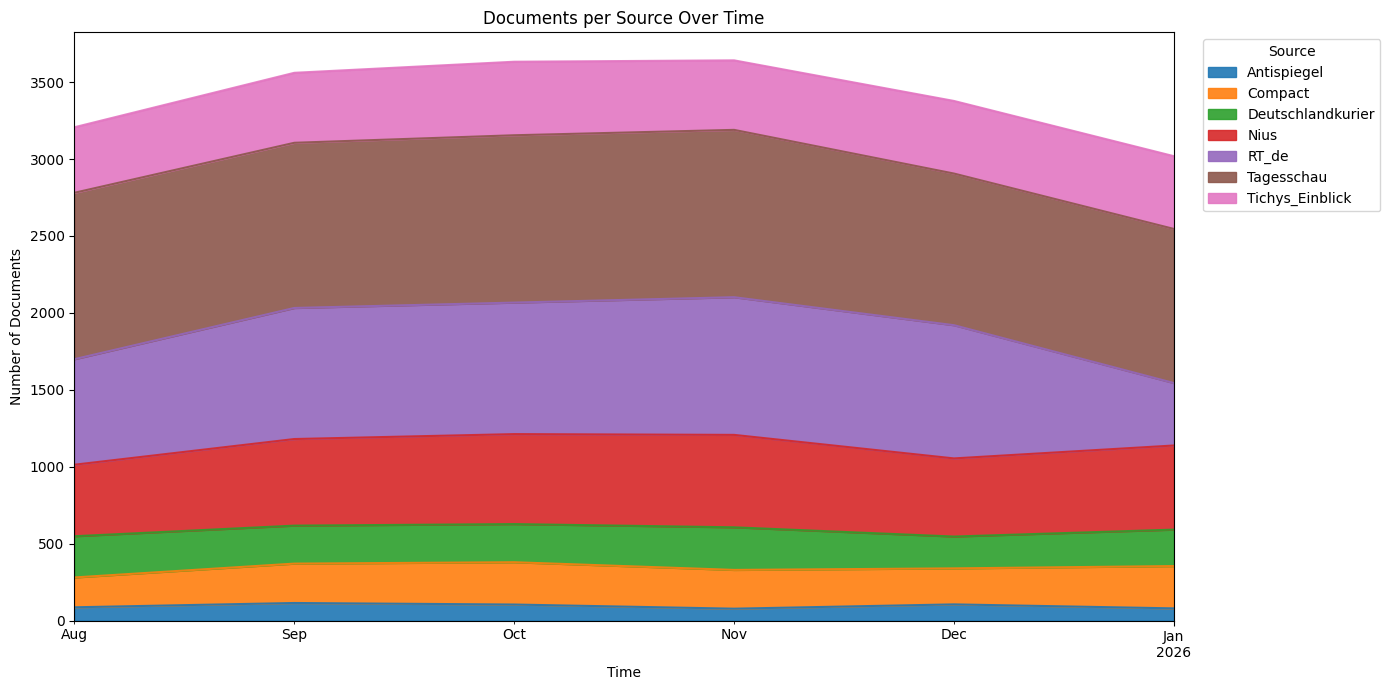

source,Antispiegel,Compact,Deutschlandkurier,Nius,RT_de,Tagesschau,Tichys_Einblick
period,,,,,,,
2025-08-01,86,194,268,465,686,1082,426
2025-09-01,114,256,247,563,852,1074,455
2025-10-01,104,275,248,585,855,1088,478
2025-11-01,77,252,277,601,895,1088,452
2025-12-01,105,234,207,508,866,986,472


In [2]:
import matplotlib.pyplot as plt

# Assumes you already have `overall_df` with columns: Date, source
df_plot = overall_df.copy()

# Parse date and keep valid rows
df_plot["Date"] = pd.to_datetime(df_plot["Date"], errors="coerce", utc=True).dt.tz_localize(None)
df_plot = df_plot.dropna(subset=["Date", "source"])

# Choose granularity: "D" (day), "W" (week), "M" (month)
freq = "M"

# Count docs per source over time
count_df = (
    df_plot
    .assign(period=df_plot["Date"].dt.to_period(freq).dt.to_timestamp())
    .groupby(["period", "source"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Plot stacked area chart
ax = count_df.plot.area(figsize=(14, 7), alpha=0.9)
ax.set_title("Documents per Source Over Time")
ax.set_xlabel("Time")
ax.set_ylabel("Number of Documents")
ax.legend(title="Source", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

count_df.head()


In [10]:
tmp = overall_df.copy()

# robust parse for mixed timezone formats (important for Tagesschau)
tmp["Date_parsed"] = pd.to_datetime(tmp["Date"], errors="coerce", utc=True)

qc = (
    tmp.groupby("source", dropna=False)
       .agg(
           rows=("Date", "size"),
           parsed_ok=("Date_parsed", lambda s: s.notna().sum()),
           parsed_na=("Date_parsed", lambda s: s.isna().sum()),
           parse_rate=("Date_parsed", lambda s: s.notna().mean()),
           min_date=("Date_parsed", "min"),
           max_date=("Date_parsed", "max"),
       )
       .sort_values("rows", ascending=False)
)

display(qc)


,rows,parsed_ok,parsed_na,parse_rate,min_date,max_date
source,,,,,,
Tagesschau,6320,6320,0,1.0,2025-08-01 00:00:00+00:00,2026-01-31 00:00:00+00:00
RT_de,4560,4560,0,1.0,2025-08-01 00:00:00+00:00,2026-01-19 00:00:00+00:00
Nius,3269,3269,0,1.0,2025-08-01 00:00:00+00:00,2026-01-31 00:00:00+00:00
Tichys_Einblick,2756,2756,0,1.0,2025-08-01 00:00:00+00:00,2026-01-31 00:00:00+00:00
Compact,1486,1486,0,1.0,2025-08-01 00:00:00+00:00,2026-01-31 00:00:00+00:00
Deutschlandkurier,1484,1484,0,1.0,2025-08-01 00:00:00+00:00,2026-01-31 00:00:00+00:00
Antispiegel,565,565,0,1.0,2025-08-01 00:00:00+00:00,2026-01-31 00:00:00+00:00


In [11]:
display(
    tmp.loc[tmp["source"].str.contains("tagesschau", case=False, na=False),
            ["source", "Date", "Date_parsed"]]
       .head(20)
)


,source,Date,Date_parsed
14120,Tagesschau,2025-09-01,2025-09-01 00:00:00+00:00
14121,Tagesschau,2025-10-01,2025-10-01 00:00:00+00:00
14122,Tagesschau,2025-10-24,2025-10-24 00:00:00+00:00
14123,Tagesschau,2025-10-02,2025-10-02 00:00:00+00:00
14124,Tagesschau,2025-09-30,2025-09-30 00:00:00+00:00
14125,Tagesschau,2025-09-22,2025-09-22 00:00:00+00:00
14126,Tagesschau,2025-08-29,2025-08-29 00:00:00+00:00
14127,Tagesschau,2025-10-22,2025-10-22 00:00:00+00:00
14128,Tagesschau,2025-08-26,2025-08-26 00:00:00+00:00
14129,Tagesschau,2025-08-09,2025-08-09 00:00:00+00:00


In [12]:
# 1) Filter mask for Tagesschau rows
mask_ts = overall_df["source"].eq("Tagesschau")

# 2) Parse timezone timestamps and keep only calendar date (as datetime64[ns])
overall_df.loc[mask_ts, "Date"] = (
    pd.to_datetime(overall_df.loc[mask_ts, "Date"], errors="coerce", utc=True)
      .dt.tz_convert("Europe/Berlin")   # optional, German local time
      .dt.tz_localize(None)             # remove timezone -> datetime64[ns]
      .dt.normalize()                   # keep date only (00:00:00)
)

# quick check
print(overall_df.loc[mask_ts, "Date"].head())
print(overall_df.loc[mask_ts, "Date"].dtype)


14120   2025-09-01
14121   2025-10-01
14122   2025-10-24
14123   2025-10-02
14124   2025-09-30
Name: Date, dtype: datetime64[us]
datetime64[us]


## BERTopic

In [13]:
import sys
from pathlib import Path
# BERTopic code lives in 1a_BERTopic/ (not BERTopic/); add it to path
_cwd = Path.cwd().resolve()
_project_root = next((p for p in [_cwd, _cwd.parent, *_cwd.parents] if (p / "1a_BERTopic").exists()), _cwd)
_bertopic_dir = _project_root / "1a_BERTopic"
if _bertopic_dir.exists() and str(_bertopic_dir) not in sys.path:
    sys.path.insert(0, str(_bertopic_dir))
from bertopic_pipeline import run_bertopic_pipeline

ModuleNotFoundError: No module named 'BERTopic.bertopic_pipeline'

In [ ]:
from bertopic_config import BERTopicConfig

In [ ]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=overall_df,
    text_col="Text",
    config=BERTopicConfig(),
    id_col="row_id",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text
analysis_result = result
analysis_result_name = "baseline overall model"
base_result_for_reduction = result

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-16 10:09:43,000 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/637 [00:00<?, ?it/s]

2026-03-16 10:11:14,312 - BERTopic - Embedding - Completed ✓
2026-03-16 10:11:14,312 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-16 10:11:25,442 - BERTopic - Dimensionality - Completed ✓
2026-03-16 10:11:25,442 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-16 10:11:27,576 - BERTopic - Cluster - Completed ✓
2026-03-16 10:11:27,580 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-16 10:11:39,385 - BERTopic - Representation - Completed ✓


In [ ]:
topic_info = analysis_result["topic_info"]
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,7787,-1_ukraine_russland_afd_merz,"[ukraine, russland, afd, merz, russischen, cdu...",[# „Deutschlandplan“ der AfD: Zwei Drittel der...
1,0,991,0_israel_hamas_gaza_gazastreifen,"[israel, hamas, gaza, gazastreifen, geiseln, i...",[US-Präsident Trump droht der Hamas in einem S...
2,1,661,1_polizei_täter_mann_messer,"[polizei, täter, mann, messer, jährige, tat, o...",[# Iraker wirft 16-Jährige vor den Zug: Das Pr...
3,2,418,2_patienten_corona_warken_krankenkassen,"[patienten, corona, warken, krankenkassen, ärz...",[US-Gesundheitsminister Robert F. Kennedy Jr. ...
4,3,408,3_migranten_merkel_migration_asyl,"[migranten, merkel, migration, asyl, 2015, flü...",[4. September: Heute vor zehn Jahren öffnete A...
5,4,318,4_venezuela_maduro_venezuelas_karibik,"[venezuela, maduro, venezuelas, karibik, venez...",[Im Kampf gegen den Drogenhandel nehmen die US...
6,5,293,5_co2_klimaschutz_klima_klimawandel,"[co2, klimaschutz, klima, klimawandel, emissio...","[Damit Deutschland klimaneutral wird, muss CO2..."
7,6,245,6_günther_zdf_lanz_ruhs,"[günther, zdf, lanz, ruhs, journalisten, böhme...",[# Das Protokoll des Angriffs auf Julia Ruhs I...
8,7,203,7_kirk_charlie_charlie kirk_kirks,"[kirk, charlie, charlie kirk, kirks, utah, mor...",[# Mord an Charlie Kirk: Die Foto-Chronik des ...
9,8,183,8_vermögenswerte_ukraine_belgien_milliarden,"[vermögenswerte, ukraine, belgien, milliarden,...",[Die EU denkt schon seit dem Beginn der Eskala...


## BERTopic per class

In [ ]:
analysis_result = analysis_result if "analysis_result" in globals() else result
analysis_result_name = (
    analysis_result_name if "analysis_result_name" in globals() else "baseline overall model"
)
print(f"Using {analysis_result_name} for topics_per_class")

topic_model = analysis_result["topic_model"]
docs = analysis_result["docs"]  # same docs used to fit this model
prepared = analysis_result["prepared_documents"]
classes = overall_df.loc[prepared["original_index"], "source"].tolist()

topics_per_class = analysis_result.get("topics_per_class")
if topics_per_class is None:
    topics_per_class = topic_model.topics_per_class(docs, classes=classes)

topic_assignments = list(analysis_result["topics"])
assignments = analysis_result.get("assignments")
if assignments is None:
    assignments = pd.DataFrame({"Class": classes, "Topic": topic_assignments})
else:
    assignments = assignments.copy()

non_outlier_class_sizes = analysis_result.get("non_outlier_class_sizes")
if non_outlier_class_sizes is None:
    non_outlier_class_sizes = (
        assignments.loc[assignments["Topic"] != -1]
        .groupby("Class")
        .size()
    )

In [ ]:
# 4) Visualize
fig = topic_model.visualize_topics_per_class(topics_per_class, top_n_topics=20)
fig.show()

In [ ]:
# 5) Topics per class: absolute count + relative share (denominator = non-outlier docs in class)

tpc_plot = topics_per_class.copy()
tpc_plot["Class_NonOutlier_Size"] = tpc_plot["Class"].map(non_outlier_class_sizes)
tpc_plot["Rel_Pct"] = np.where(
    tpc_plot["Class_NonOutlier_Size"] > 0,
    (tpc_plot["Frequency"] / tpc_plot["Class_NonOutlier_Size"]) * 100,
    np.nan,
)

# Match topic selection used in the per-class visualization
top_n_topics = 20
freq_df = topic_model.get_topic_freq()
selected_topics = sorted(freq_df.loc[freq_df["Topic"] != -1, "Topic"].head(top_n_topics).tolist())

topic_names = {
    key: (value[:40] + "..." if len(value) > 40 else value)
    for key, value in topic_model.topic_labels_.items()
}
tpc_plot["Name"] = tpc_plot["Topic"].map(topic_names)

colors = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#D55E00", "#0072B2", "#CC79A7"]

fig_abs_rel = go.Figure()
for idx, topic in enumerate(selected_topics):
    trace_data = tpc_plot.loc[tpc_plot["Topic"] == topic].copy()
    if trace_data.empty:
        continue

    trace_data = trace_data.sort_values("Class")
    topic_name = trace_data["Name"].iloc[0]
    visible = True if idx == 0 else "legendonly"

    fig_abs_rel.add_trace(
        go.Bar(
            y=trace_data["Class"],
            x=trace_data["Frequency"],
            orientation="h",
            marker_color=colors[idx % len(colors)],
            name=topic_name,
            visible=visible,
            text=[
                f"{int(c)} ({p:.2f}%)"
                for c, p in zip(trace_data["Frequency"], trace_data["Rel_Pct"])
            ],
            textposition="auto",
            customdata=np.stack(
                [
                    trace_data["Words"].astype(str).to_numpy(),
                    trace_data["Rel_Pct"].to_numpy(),
                    trace_data["Class_NonOutlier_Size"].to_numpy(),
                    trace_data["Topic"].to_numpy(),
                ],
                axis=-1,
            ),
            hovertemplate=(
                "<b>Topic %{customdata[3]}</b><br>"
                "Words: %{customdata[0]}<br>"
                "Class: %{y}<br>"
                "Absolute count: %{x}<br>"
                "Relative in class (non-outlier denom): %{customdata[1]:.2f}%<br>"
                "Non-outlier class size: %{customdata[2]}<extra></extra>"
            ),
        )
    )

fig_abs_rel.update_layout(
    template="simple_white",
    title="<b>Topics per Class (absolute count + share of non-outlier docs in class)</b>",
    xaxis_title="Absolute count (bar label: absolute + relative %)",
    yaxis_title="Class",
    width=1250,
    height=900,
    legend=dict(title="<b>Global Topic Representation</b>"),
)
fig_abs_rel.show()

In [ ]:
# Pivot table: topics by class/outlet (absolute counts)
tpc_table = topics_per_class.loc[topics_per_class["Topic"] != -1].copy()

topic_words_map = (
    tpc_table.groupby("Topic")["Words"]
    .first()
    .astype(str)
    .to_dict()
)

topic_class_pivot = (
    tpc_table.pivot_table(
        index="Topic",
        columns="Class",
        values="Frequency",
        aggfunc="sum",
        fill_value=0,
    )
    .astype(int)
)

topic_class_pivot["Total"] = topic_class_pivot.sum(axis=1)
class_cols = [col for col in topic_class_pivot.columns if col != "Total"]
topic_class_pivot = topic_class_pivot.sort_values("Total", ascending=False).reset_index()

topic_class_pivot["TopicName"] = (
    topic_class_pivot["Topic"].map(topic_names).fillna(topic_class_pivot["Topic"].map(topic_words_map))
)
topic_class_pivot["TopicLabel"] = (
    "Topic " + topic_class_pivot["Topic"].astype(str) + " — " + topic_class_pivot["TopicName"].astype(str)
)

topic_class_pivot = topic_class_pivot[["Topic", "TopicLabel", "Total", *class_cols]].copy()

display(
    topic_class_pivot.style
    .hide(axis="index")
    .background_gradient(subset=["Total", *class_cols], cmap="Blues")
    .format({col: "{:,.0f}" for col in ["Total", *class_cols]})
)

Topic,TopicLabel,Total,Antispiegel,Compact,Deutschlandkurier,Nius,RT_de,Tagesschau,Tichys_Einblick
0,Topic 0 — 0_israel_hamas_gaza_gazastreifen,991,19,33,6,161,235,439,98
1,Topic 1 — 1_polizei_täter_mann_messer,661,0,70,76,286,78,85,66
2,Topic 2 — 2_patienten_corona_warken_krankenkassen,418,1,32,28,44,41,215,57
3,Topic 3 — 3_migranten_merkel_migration_asyl,408,3,42,72,95,37,80,79
4,Topic 4 — 4_venezuela_maduro_venezuelas_karibik,318,6,27,6,16,153,96,14
5,Topic 5 — 5_co2_klimaschutz_klima_klimawandel,293,1,7,34,60,10,130,51
6,Topic 6 — 6_günther_zdf_lanz_ruhs,245,11,21,25,84,15,12,77
7,Topic 7 — 7_kirk_charlie_charlie kirk_kirks,203,4,34,24,67,25,24,25
8,Topic 8 — 8_vermögenswerte_ukraine_belgien_milliar...,183,17,3,12,3,105,29,14
9,Topic 9 — 9_wegner_berliner_berlin_stromausfall,172,0,18,20,63,16,24,31


In [ ]:
if "fig_abs_rel" not in globals():
    raise NameError("fig_abs_rel is not defined. Run the previous visualization cell first.")

output_path = Path("BERTopic/outputs/topics_per_class_abs_rel.html")
output_path.parent.mkdir(parents=True, exist_ok=True)
fig_abs_rel.write_html(output_path, full_html=True, include_plotlyjs=True)
print(f"Saved interactive HTML to: {output_path.resolve()}")

Saved interactive HTML to: /Users/MattisHaumann/Dev/Thesis/data preprocessing/BERTopic/outputs/topics_per_class_abs_rel.html


In [ ]:
# 6) Normalized topic prevalence per outlet (top 15 topics, non-outlier denominator)

# Top topics globally (excluding outliers)
top_n_topics = 15
freq_df = topic_model.get_topic_freq()
top_topics = freq_df.loc[freq_df["Topic"] != -1, "Topic"].head(top_n_topics).tolist()

# Keep outlet order as they appear in the prepared corpus
class_order = pd.Index(assignments["Class"].drop_duplicates().tolist(), name="Outlet")

# Numerators from topics_per_class + normalized share
prevalence_long = (
    topics_per_class.loc[topics_per_class["Topic"].isin(top_topics), ["Class", "Topic", "Frequency"]]
    .assign(NonOutlierDocs=lambda d: d["Class"].map(non_outlier_class_sizes))
)
prevalence_long["Share"] = np.where(
    prevalence_long["NonOutlierDocs"] > 0,
    prevalence_long["Frequency"] / prevalence_long["NonOutlierDocs"],
    np.nan,
)

# Matrix: outlets in rows, top topics in columns
prevalence_matrix = (
    prevalence_long
    .pivot(index="Class", columns="Topic", values="Share")
    .reindex(index=class_order, columns=top_topics)
    .fillna(0.0)
)

# Human-readable column labels
label_lookup = {t: topic_model.topic_labels_.get(t, str(t)) for t in top_topics}
prevalence_matrix.columns = [
    f"{t} | {label_lookup[t].split('_', 1)[-1][:32]}"
    for t in top_topics
]
prevalence_matrix.index.name = "Outlet"

# Show numeric table (share as percentage)
display(prevalence_matrix.style.format("{:.2%}"))

# Heatmap depiction
fig_prevalence = go.Figure(
    data=go.Heatmap(
        z=(prevalence_matrix * 100).to_numpy(),
        x=prevalence_matrix.columns,
        y=prevalence_matrix.index,
        colorscale="Blues",
        colorbar=dict(title="Share (%)"),
        hovertemplate=(
            "Outlet: %{y}<br>"
            "Topic: %{x}<br>"
            "Share of non-outlier docs: %{z:.2f}%<extra></extra>"
        ),
    )
)

fig_prevalence.update_layout(
    template="simple_white",
    title="<b>Normalized Topic Prevalence per Outlet (Top 15 Topics)</b>",
    xaxis_title="Top 15 topics (global, excluding -1)",
    yaxis_title="Outlet",
    width=1400,
    height=650,
)
fig_prevalence.show()

# Optional export
output_path = Path("BERTopic/outputs/topic_prevalence_matrix_top15_non_outlier.html")
output_path.parent.mkdir(parents=True, exist_ok=True)
fig_prevalence.write_html(output_path, full_html=True, include_plotlyjs=True)
print(f"Saved heatmap HTML to: {output_path.resolve()}")

,0 | israel_hamas_gaza_gazastreifen,1 | polizei_täter_mann_messer,2 | patienten_corona_warken_krankenk,3 | migranten_merkel_migration_asyl,4 | venezuela_maduro_venezuelas_kari,5 | co2_klimaschutz_klima_klimawande,6 | günther_zdf_lanz_ruhs,7 | kirk_charlie_charlie kirk_kirks,8 | vermögenswerte_ukraine_belgien_m,9 | wegner_berliner_berlin_stromausf,10 | ukraine_selenskyj_russland_putin,11 | merz_friedrich merz_friedrich_ka,12 | dax_dollar_anleger_punkten,13 | russland_nato_ukraine_russischen,14 | rentenpaket_rente_jungen_union
Outlet,,,,,,,,,,,,,,,
Antispiegel,6.01%,0.00%,0.32%,0.95%,1.90%,0.32%,3.48%,1.27%,5.38%,0.00%,3.16%,0.32%,0.00%,6.65%,0.00%
Compact,4.26%,9.03%,4.13%,5.42%,3.48%,0.90%,2.71%,4.39%,0.39%,2.32%,0.52%,1.03%,0.00%,2.06%,0.13%
Nius,7.39%,13.12%,2.02%,4.36%,0.73%,2.75%,3.85%,3.07%,0.14%,2.89%,0.69%,2.57%,0.00%,0.05%,2.11%
RT_de,8.98%,2.98%,1.57%,1.41%,5.85%,0.38%,0.57%,0.96%,4.01%,0.61%,2.71%,0.27%,0.08%,3.75%,0.11%
Tichys_Einblick,6.29%,4.24%,3.66%,5.07%,0.90%,3.28%,4.95%,1.61%,0.90%,1.99%,0.32%,3.28%,0.58%,0.06%,1.80%
Deutschlandkurier,0.68%,8.61%,3.17%,8.15%,0.68%,3.85%,2.83%,2.72%,1.36%,2.27%,1.25%,2.60%,0.00%,0.45%,1.59%
Tagesschau,10.34%,2.00%,5.07%,1.89%,2.26%,3.06%,0.28%,0.57%,0.68%,0.57%,1.27%,0.52%,3.35%,0.19%,1.32%


Saved heatmap HTML to: /Users/MattisHaumann/Dev/Thesis/data preprocessing/BERTopic/outputs/topic_prevalence_matrix_top15_non_outlier.html


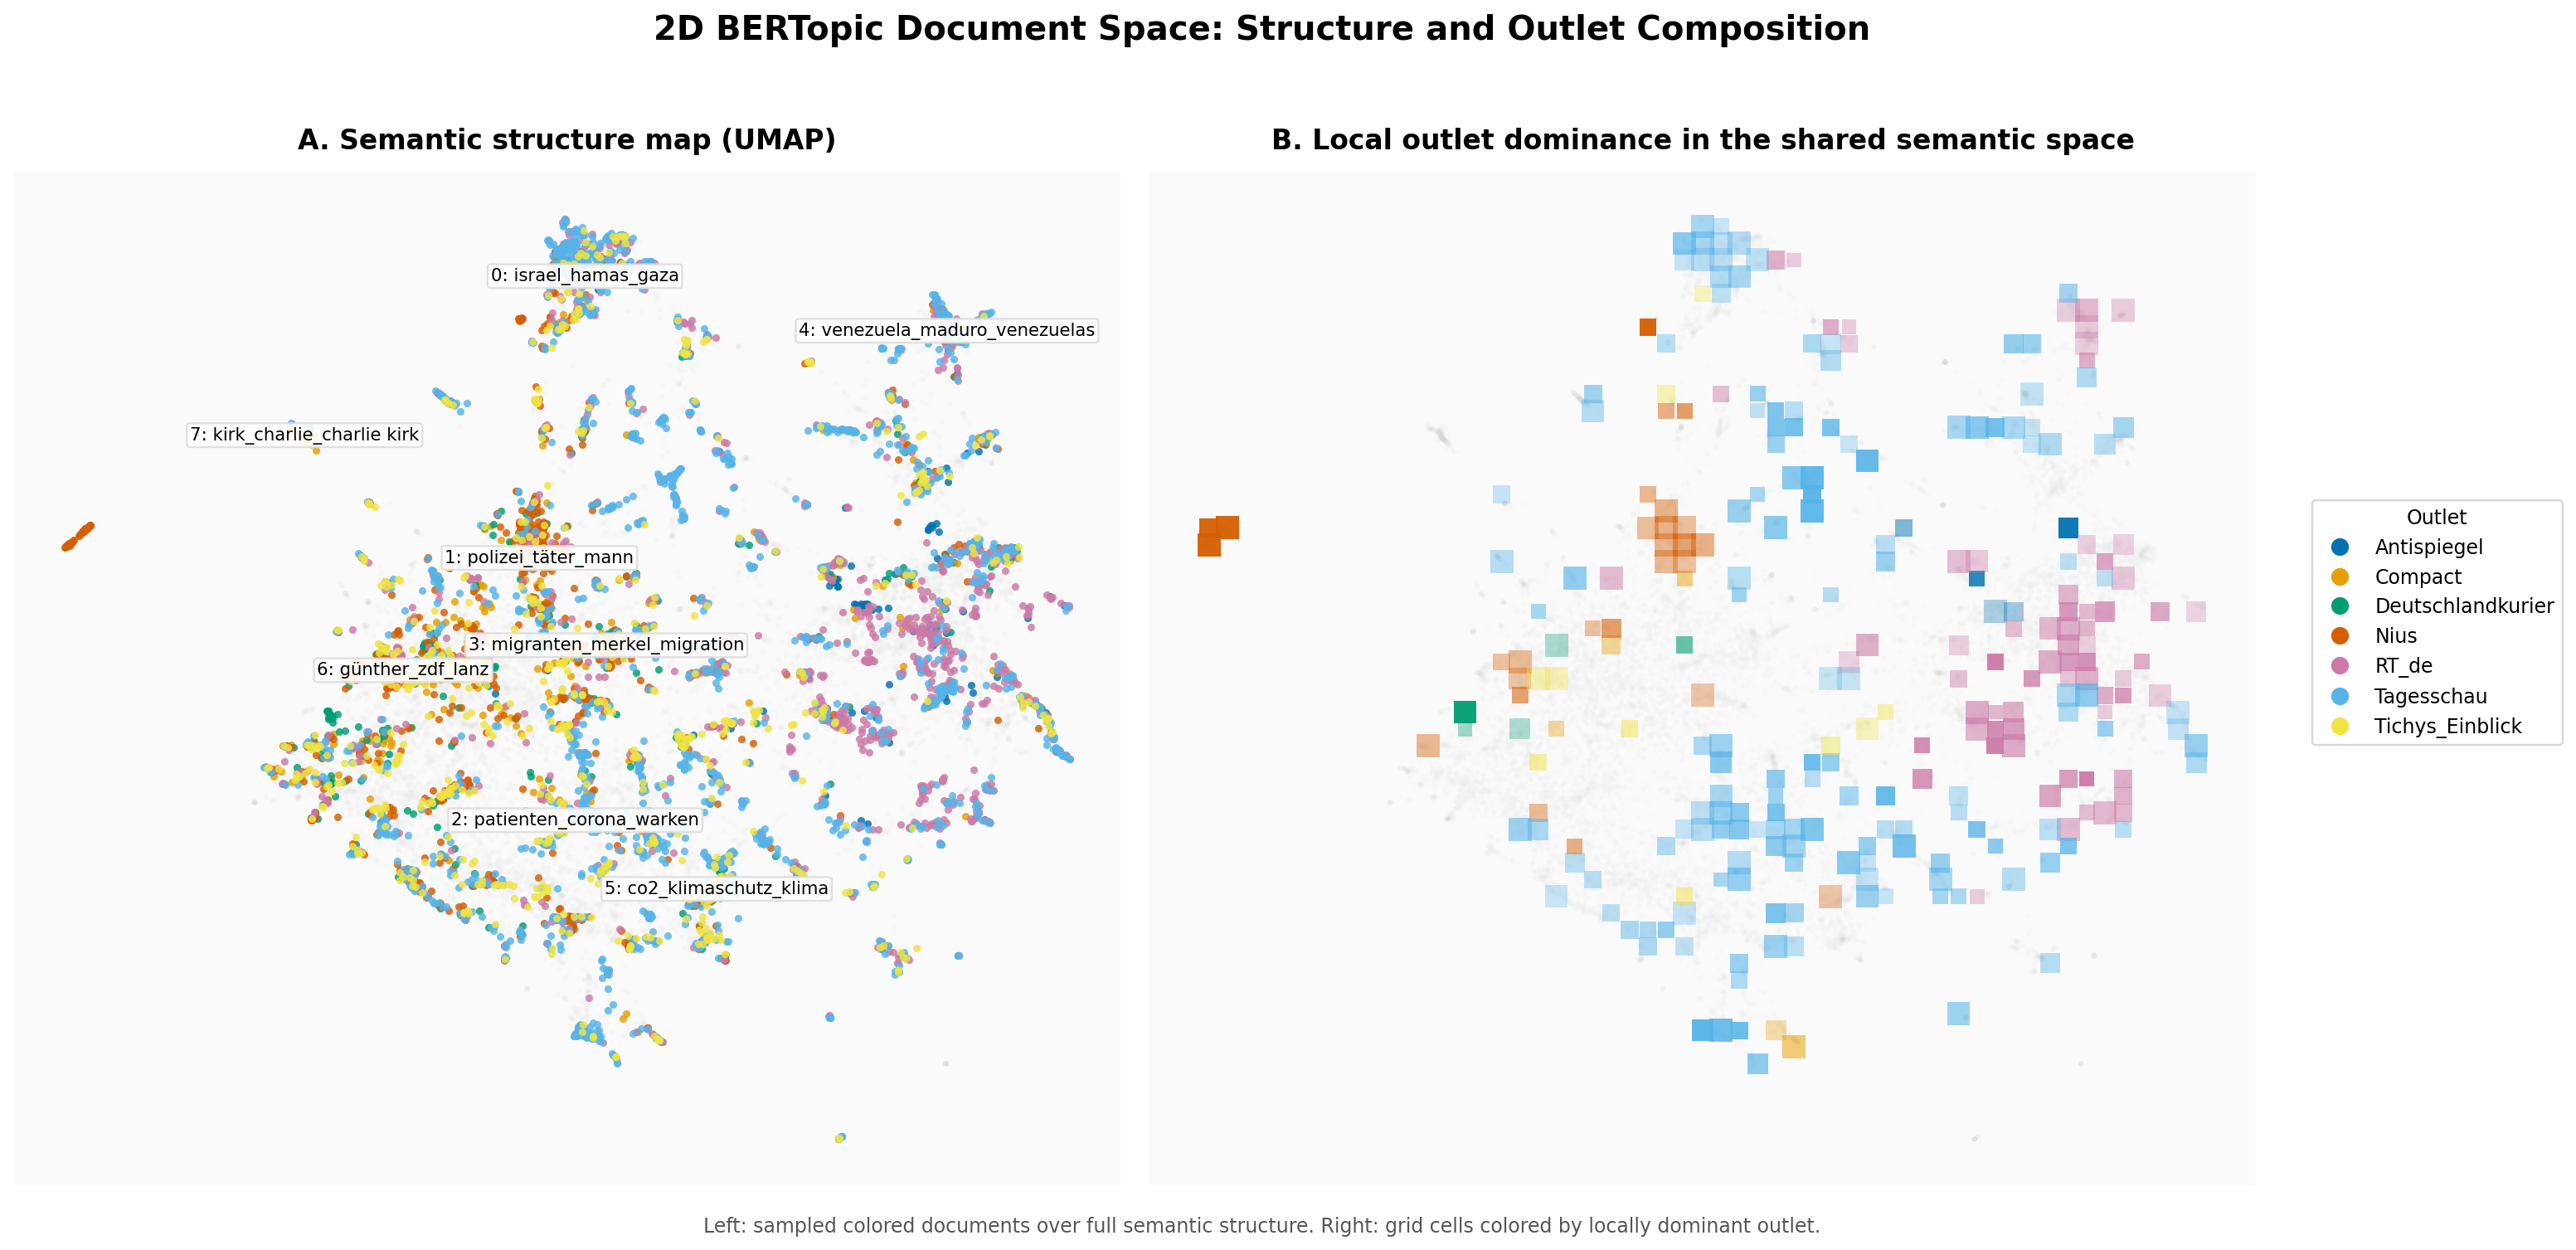

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# 1) Embeddings + 2D reduction
# ============================================================
embeddings = topic_model._extract_embeddings(docs, method="document")

reducer_name = None
try:
    from bertopic_pipeline import _suppress_numba_cache_during_import
    with _suppress_numba_cache_during_import():
        from umap import UMAP

    reducer = UMAP(
        n_neighbors=12,
        n_components=2,
        min_dist=0.05,
        metric="cosine",
        random_state=42
    )
    coords = reducer.fit_transform(embeddings)
    reducer_name = "UMAP"
except Exception as exc:
    from sklearn.manifold import TSNE
    print(f"UMAP unavailable ({exc}); falling back to TSNE.")
    reducer = TSNE(
        n_components=2,
        perplexity=30,
        init="pca",
        learning_rate="auto",
        random_state=42
    )
    coords = reducer.fit_transform(embeddings)
    reducer_name = "TSNE"

# ============================================================
# 2) Plot dataframe
# ============================================================
plot_df = pd.DataFrame(coords, columns=["x", "y"])
plot_df["topic"] = topic_model.topics_
plot_df["source"] = classes

inliers = plot_df[plot_df["topic"] != -1].copy()

# ============================================================
# 3) Topic labels: fewer = clearer
# ============================================================
top_n_topics = 8
top_topics = (
    topic_model.get_topic_freq()
    .query("Topic != -1")
    .head(top_n_topics)["Topic"]
    .tolist()
)

labels_df = inliers[inliers["topic"].isin(top_topics)].copy()

# ============================================================
# 4) Colorblind-friendly palette
# ============================================================
source_order = sorted(inliers["source"].unique().tolist())

source_colors = {
    "Antispiegel": "#0072B2",         # blue
    "Compact": "#E69F00",             # orange
    "Deutschlandkurier": "#009E73",   # green
    "Nius": "#D55E00",                # vermillion
    "RT_de": "#CC79A7",               # purple/pink
    "Tagesschau": "#56B4E9",          # sky blue
    "Tichys_Einblick": "#F0E442",     # yellow
}

fallback = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#56B4E9", "#F0E442"]
for i, src in enumerate(source_order):
    if src not in source_colors:
        source_colors[src] = fallback[i % len(fallback)]

# ============================================================
# 5) Figure layout
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 9), dpi=170)
ax1, ax2 = axes

for ax in axes:
    ax.set_facecolor("#FAFAFA")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

# ============================================================
# PANEL A: structure map with sampled colored points
# ============================================================
# Faint background: all docs
ax1.scatter(
    plot_df["x"], plot_df["y"],
    c="#CFCFCF", s=7, alpha=0.05, linewidths=0,
    rasterized=True, zorder=1
)

# Sample colored docs per outlet to avoid overplotting
sample_frac = 0.45   # adjust 0.30–0.60
sampled_parts = []
for src in source_order:
    sub = inliers[inliers["source"] == src]
    n = len(sub)
    take = max(1, int(sample_frac * n))
    sampled = sub.sample(n=take, random_state=42) if take < n else sub
    sampled_parts.append(sampled)

sampled_df = pd.concat(sampled_parts, axis=0)

for src in source_order:
    sub = sampled_df[sampled_df["source"] == src]
    ax1.scatter(
        sub["x"], sub["y"],
        s=15,
        alpha=0.82,
        color=source_colors[src],
        linewidths=0,
        rasterized=True,
        zorder=2
    )

# Topic labels at representative point near centroid
for topic_id in top_topics:
    pts = labels_df.loc[labels_df["topic"] == topic_id, ["x", "y"]].to_numpy()
    if len(pts) == 0:
        continue

    centroid = pts.mean(axis=0)
    dists = ((pts - centroid) ** 2).sum(axis=1)
    label_xy = pts[np.argmin(dists)]

    words = topic_model.get_topic(topic_id)
    label = "_".join([w for w, _ in words[:3]]) if words else str(topic_id)

    ax1.text(
        label_xy[0], label_xy[1],
        f"{topic_id}: {label}",
        fontsize=9,
        ha="center",
        va="center",
        color="black",
        bbox=dict(
            facecolor="white",
            edgecolor="#DDDDDD",
            alpha=0.90,
            boxstyle="round,pad=0.18"
        ),
        zorder=3
    )

ax1.set_title(
    f"A. Semantic structure map ({reducer_name})",
    fontsize=14, weight="semibold", pad=12
)

# ============================================================
# PANEL B: local outlet dominance map
# ============================================================
# Build grid
n_bins = 55
x_edges = np.linspace(plot_df["x"].min(), plot_df["x"].max(), n_bins + 1)
y_edges = np.linspace(plot_df["y"].min(), plot_df["y"].max(), n_bins + 1)

dominance_df = inliers.copy()
dominance_df["bx"] = np.clip(np.digitize(dominance_df["x"], x_edges) - 1, 0, n_bins - 1)
dominance_df["by"] = np.clip(np.digitize(dominance_df["y"], y_edges) - 1, 0, n_bins - 1)

# Counts per cell and source
cell_source_counts = (
    dominance_df.groupby(["bx", "by", "source"])
    .size()
    .reset_index(name="n")
)

# Total per cell
cell_totals = (
    cell_source_counts.groupby(["bx", "by"])["n"]
    .sum()
    .reset_index(name="total")
)

# Dominant source per cell
idx = cell_source_counts.groupby(["bx", "by"])["n"].idxmax()
dominant_cells = cell_source_counts.loc[idx].copy()
dominant_cells = dominant_cells.merge(cell_totals, on=["bx", "by"], how="left")
dominant_cells["share"] = dominant_cells["n"] / dominant_cells["total"]

# Keep only informative cells
min_docs = 8
min_share = 0.45
dominant_cells = dominant_cells[
    (dominant_cells["total"] >= min_docs) &
    (dominant_cells["share"] >= min_share)
].copy()

# Cell centers
dominant_cells["x"] = (x_edges[dominant_cells["bx"]] + x_edges[dominant_cells["bx"] + 1]) / 2
dominant_cells["y"] = (y_edges[dominant_cells["by"]] + y_edges[dominant_cells["by"] + 1]) / 2

# Faint corpus background
ax2.scatter(
    plot_df["x"], plot_df["y"],
    c="#D6D6D6", s=6, alpha=0.03, linewidths=0,
    rasterized=True, zorder=1
)

# Plot dominant cells
for src in source_order:
    sub = dominant_cells[dominant_cells["source"] == src]
    if len(sub) == 0:
        continue

    # stronger alpha when dominance is stronger
    alphas = 0.30 + 0.65 * ((sub["share"] - min_share) / (1 - min_share)).clip(0, 1)
    sizes = (25 + 4 * sub["total"]).clip(25, 140)

    ax2.scatter(
        sub["x"], sub["y"],
        s=sizes,
        c=source_colors[src],
        alpha=alphas,
        marker="s",
        linewidths=0,
        rasterized=True,
        zorder=2
    )

ax2.set_title(
    "B. Local outlet dominance in the shared semantic space",
    fontsize=14, weight="semibold", pad=12
)

# ============================================================
# Legend
# ============================================================
legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label=src,
        markerfacecolor=source_colors[src],
        markeredgecolor="none",
        markersize=9
    )
    for src in source_order
]

fig.legend(
    handles=legend_handles,
    title="Outlet",
    loc="center left",
    bbox_to_anchor=(0.91, 0.5),
    frameon=True
)

fig.suptitle(
    "2D BERTopic Document Space: Structure and Outlet Composition",
    fontsize=17, weight="bold", y=0.98
)

fig.text(
    0.5, 0.02,
    "Left: sampled colored documents over full semantic structure. Right: grid cells colored by locally dominant outlet.",
    ha="center", fontsize=10, color="#555555"
)

plt.tight_layout(rect=[0, 0.04, 0.90, 0.95])
plt.show()

## Actors prevalent

In [ ]:
import plotly.express as px

target_forms = {
    "Trump": ["trump"],
    "Weidel": ["weidel"],
    "Merz": ["merz"],
    "Netanhjahu": ["netanhjahu", "netanjahu", "netanyahu"],
    "Putin": ["putin"],
    "Selenski": ["selenski", "selensky", "selenskyj", "selenskij", "zelensky", "zelenskyy"],
    "Scholz": ["scholz"],
    "Habeck": ["habeck"],
    "Baerbock": ["baerbock"],
    "Söder": ["söder", "soeder"],
    "Wagenknecht": ["wagenknecht"],
    "Höcke": ["höcke", "hoecke"],
    "Lindner": ["lindner"],
    "Klingbeil": ["klingbeil"],
    "Biden": ["biden"],
    "Macron": ["macron"],
    "Orban": ["orbán", "orban"],
    "Erdogan": ["erdoğan", "erdogan"],
    "von_der_leyen": ["leyen", "vonderleyen", "vdl"],  # multi-token name workaround
    "Kallas": ["kallas"],
    "Maduro": ["maduro"],}


form_to_target = {
    form: target
    for target, forms in target_forms.items()
    for form in forms
}

tokens = (
    overall_df[["source", "Title"]]
    .assign(token=lambda d: d["Title"].fillna("").str.casefold().str.findall(r"\b[\wäöüß-]+\b"))
    .explode("token")
    .dropna(subset=["token"])
)

counts = (
    tokens[tokens["token"].isin(form_to_target)]
    .assign(Target=lambda d: d["token"].map(form_to_target))
    .groupby(["source", "Target"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=target_forms.keys(), fill_value=0)
    .sort_index()
)

# Denominator: number of non-empty titles per outlet
titles_per_outlet = (
    overall_df.assign(has_title=overall_df["Title"].fillna("").str.strip().ne(""))
    .groupby("source")["has_title"]
    .sum()
    .reindex(counts.index)
)

relative = counts.div(titles_per_outlet, axis=0).fillna(0) * 100  # percent of titles

display(relative.style.format("{:.2f}%"))

fig = px.imshow(
    relative,
    text_auto=".2f",
    color_continuous_scale="Blues",
    labels={"x": "Target", "y": "Outlet", "color": "% of titles"},
    title="Target word mentions in Title relative to number of titles per outlet (%)",
)
fig.update_traces(
    customdata=counts.to_numpy(),
    hovertemplate=(
        "Outlet: %{y}<br>"
        "Target: %{x}<br>"
        "Share of titles: %{z:.2f}%<br>"
        "Absolute count: %{customdata}<extra></extra>"
    ),
)
fig.show()

Target,Trump,Weidel,Merz,Netanhjahu,Putin,Selenski,Scholz,Habeck,Baerbock,Söder,Wagenknecht,Höcke,Lindner,Klingbeil,Biden,Macron,Orban,Erdogan,von_der_leyen,Kallas,Maduro
source,,,,,,,,,,,,,,,,,,,,,
Antispiegel,6.19%,0.00%,1.77%,0.71%,3.89%,3.36%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.18%,0.71%,0.00%,0.35%,0.00%,0.00%
Compact,2.76%,0.87%,3.30%,0.20%,1.28%,0.20%,0.00%,0.20%,0.00%,0.07%,0.40%,0.61%,0.00%,0.00%,0.00%,0.20%,0.20%,0.00%,0.13%,0.07%,0.13%
Deutschlandkurier,5.05%,1.48%,6.94%,0.00%,1.68%,1.95%,0.13%,0.27%,0.20%,1.21%,0.07%,0.40%,0.00%,0.40%,0.07%,0.00%,1.48%,0.07%,0.40%,0.00%,0.20%
Nius,2.29%,0.37%,7.25%,0.24%,0.40%,0.28%,0.03%,0.28%,0.18%,0.76%,0.21%,0.09%,0.00%,0.89%,0.03%,0.12%,0.12%,0.03%,0.18%,0.03%,0.24%
RT_de,7.48%,0.26%,1.69%,0.59%,3.36%,2.81%,0.04%,0.15%,0.02%,0.15%,0.13%,0.02%,0.04%,0.15%,0.07%,0.92%,0.77%,0.15%,0.68%,0.42%,0.75%
Tagesschau,4.05%,0.02%,1.09%,0.30%,0.84%,1.04%,0.00%,0.03%,0.05%,0.17%,0.09%,0.02%,0.02%,0.30%,0.00%,0.19%,0.08%,0.02%,0.09%,0.05%,0.14%
Tichys_Einblick,2.83%,0.11%,6.10%,0.04%,0.54%,0.40%,0.04%,0.33%,0.04%,0.22%,0.11%,0.00%,0.07%,0.94%,0.00%,0.40%,0.40%,0.00%,0.83%,0.04%,0.07%


## Prepare Outlier-Reduced Second Pass

Reduce outliers on the same baseline overall model used for all visualizations and tables above. After running the next cells, the notebook switches `analysis_result` to the reduced model so the same topics-per-class cells can be rerun on the reduced assignments.

In [ ]:
base_result_for_reduction = result

baseline_outlier_summary = pd.DataFrame([
    {
        "Variant": "baseline overall model",
        "Non_Outlier_Topics": int(base_result_for_reduction["topic_info"].query("Topic != -1").shape[0]),
        "Outlier_Count": int((pd.Series(base_result_for_reduction["topics"]) == -1).sum()),
    }
])

display(baseline_outlier_summary)
display(base_result_for_reduction["topic_info"].head(20))

## Outlier Reduction

Apply the same c-TF-IDF threshold outlier-reduction method (`threshold=0.10`) used in the individual outlet notebooks to the same baseline overall model used above. The cell stores the reduced result in `result_overall_reduced`, switches `analysis_result` to that reduced model, and prepares the same topics-per-class inputs for a second pass.

In [ ]:
from copy import deepcopy
import pandas as pd

overall_result_for_reduction = base_result_for_reduction if "base_result_for_reduction" in globals() else result
topic_model_overall = overall_result_for_reduction["topic_model"]
docs_overall = list(overall_result_for_reduction["docs"])
topics_overall = list(overall_result_for_reduction["topics"])
prepared_docs = overall_result_for_reduction["prepared_documents"].copy()
classes_overall = overall_df.loc[prepared_docs["original_index"], "source"].tolist()
baseline_topic_ids = {topic for topic in topics_overall if topic != -1}

new_topics_ctfidf_threshold = topic_model_overall.reduce_outliers(
    docs_overall,
    topics_overall,
    strategy="c-tf-idf",
    threshold=0.10,
)
new_topics_ctfidf_threshold = list(new_topics_ctfidf_threshold)

redistributed_topic_ids = {topic for topic in new_topics_ctfidf_threshold if topic != -1}
unexpected_topic_ids = sorted(redistributed_topic_ids - baseline_topic_ids)
if unexpected_topic_ids:
    raise ValueError(
        f"Outlier reduction introduced new topic ids: {unexpected_topic_ids}. "
        "This notebook should only redistribute -1 documents into existing topics."
    )

topic_model_ctfidf_threshold = deepcopy(topic_model_overall)
vectorizer_same = deepcopy(topic_model_overall.vectorizer_model)
ctfidf_same = deepcopy(topic_model_overall.ctfidf_model)
representation_same = deepcopy(topic_model_overall.representation_model)

topic_model_ctfidf_threshold.update_topics(
    docs_overall,
    topics=new_topics_ctfidf_threshold,
    vectorizer_model=vectorizer_same,
    ctfidf_model=ctfidf_same,
    representation_model=representation_same,
    top_n_words=topic_model_overall.top_n_words,
)
topic_model_ctfidf_threshold.topics_ = list(new_topics_ctfidf_threshold)

topic_info_ctfidf_threshold = topic_model_ctfidf_threshold.get_topic_info().copy()
topic_name_map_reduced = dict(zip(topic_info_ctfidf_threshold["Topic"], topic_info_ctfidf_threshold["Name"]))

doc_info_reduced = overall_result_for_reduction["doc_info"].copy()
doc_info_reduced["Topic"] = list(new_topics_ctfidf_threshold)
if "Name" in doc_info_reduced.columns:
    doc_info_reduced["Name"] = doc_info_reduced["Topic"].map(topic_name_map_reduced)

assignments_compare = pd.DataFrame({
    "Class": classes_overall,
    "Topic_Before": topics_overall,
    "Topic_After": new_topics_ctfidf_threshold,
})
outlier_reduction_by_class = (
    assignments_compare.groupby("Class", sort=False)
    .apply(
        lambda group: pd.Series({
            "Docs": len(group),
            "Outliers_Before": int((group["Topic_Before"] == -1).sum()),
            "Outliers_After": int((group["Topic_After"] == -1).sum()),
            "Recovered_From_Outlier": int(((group["Topic_Before"] == -1) & (group["Topic_After"] != -1)).sum()),
            "New_Outliers": int(((group["Topic_Before"] != -1) & (group["Topic_After"] == -1)).sum()),
        })
    )
    .reset_index()
)

topics_per_class_reduced = topic_model_ctfidf_threshold.topics_per_class(docs_overall, classes=classes_overall)
assignments_reduced = pd.DataFrame({"Class": classes_overall, "Topic": new_topics_ctfidf_threshold})
non_outlier_class_sizes_reduced = (
    assignments_reduced.loc[assignments_reduced["Topic"] != -1]
    .groupby("Class")
    .size()
)

summary_final = pd.DataFrame([
    {
        "Variant": "baseline overall model",
        "Outlier_Count": int((pd.Series(topics_overall) == -1).sum()),
    },
    {
        "Variant": "outlier-reduced overall model",
        "Outlier_Count": int((pd.Series(new_topics_ctfidf_threshold) == -1).sum()),
    },
])
display(summary_final)
display(outlier_reduction_by_class)
display(topic_info_ctfidf_threshold.head(20))

result_overall_reduced = dict(overall_result_for_reduction)
result_overall_reduced["topic_model"] = topic_model_ctfidf_threshold
result_overall_reduced["topics"] = list(new_topics_ctfidf_threshold)
result_overall_reduced["topic_info"] = topic_info_ctfidf_threshold
result_overall_reduced["doc_info"] = doc_info_reduced
result_overall_reduced["topics_per_class"] = topics_per_class_reduced.copy()
result_overall_reduced["non_outlier_class_sizes"] = non_outlier_class_sizes_reduced.copy()
result_overall_reduced["assignments"] = assignments_reduced.copy()
result_overall_reduced["outlier_reduction_by_class"] = outlier_reduction_by_class.copy()

analysis_result = result_overall_reduced
analysis_result_name = "outlier-reduced overall model"

topic_model = result_overall_reduced["topic_model"]
docs = result_overall_reduced["docs"]
prepared = result_overall_reduced["prepared_documents"]
classes = classes_overall
topics_per_class = result_overall_reduced["topics_per_class"].copy()
assignments = result_overall_reduced["assignments"].copy()
non_outlier_class_sizes = result_overall_reduced["non_outlier_class_sizes"].copy()

print("Active analysis result switched to outlier-reduced overall model.")
print("Rerun the cells from `## BERTopic per class` onward to reproduce the same tables and visualizations on the reduced model.")

In [ ]:
import shutil
from pathlib import Path

save_dir = Path("/Users/MattisHaumann/Dev/Thesis/BERTopic/outputs/overall_model")
if save_dir.exists():
    shutil.rmtree(save_dir)

topic_model_ctfidf_threshold.save(
    str(save_dir),
    serialization="safetensors",
    save_ctfidf=True,
    save_embedding_model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
)
print(f"Saved reduced overall model to: {save_dir}")

Saved reduced overall model to: /Users/MattisHaumann/Dev/Thesis/BERTopic/outputs/overall_model


### 2D semantic map (reduced model: absolute + relative)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

topic_model = topic_model_ctfidf_threshold
docs = docs_overall
classes = classes_overall

# ============================================================
# 1) Embeddings + 2D reduction
# ============================================================
embeddings = topic_model._extract_embeddings(docs, method="document")

reducer_name = None
try:
    from BERTopic.bertopic_pipeline import _suppress_numba_cache_during_import
    with _suppress_numba_cache_during_import():
        from umap import UMAP

    reducer = UMAP(
        n_neighbors=12,
        n_components=2,
        min_dist=0.05,
        metric="cosine",
        random_state=42
    )
    coords = reducer.fit_transform(embeddings)
    reducer_name = "UMAP"
except Exception as exc:
    from sklearn.manifold import TSNE
    print(f"UMAP unavailable ({exc}); falling back to TSNE.")
    reducer = TSNE(
        n_components=2,
        perplexity=30,
        init="pca",
        learning_rate="auto",
        random_state=42
    )
    coords = reducer.fit_transform(embeddings)
    reducer_name = "TSNE"

# ============================================================
# 2) Plot dataframe
# ============================================================
plot_df = pd.DataFrame(coords, columns=["x", "y"])
plot_df["topic"] = topic_model.topics_
plot_df["source"] = classes

inliers = plot_df[plot_df["topic"] != -1].copy()

# ============================================================
# 3) Topic labels: fewer = clearer
# ============================================================
top_n_topics = 8
top_topics = (
    topic_model.get_topic_freq()
    .query("Topic != -1")
    .head(top_n_topics)["Topic"]
    .tolist()
)

labels_df = inliers[inliers["topic"].isin(top_topics)].copy()

# ============================================================
# 4) Colorblind-friendly palette
# ============================================================
source_order = sorted(inliers["source"].unique().tolist())

source_colors = {
    "Antispiegel": "#0072B2",
    "Compact": "#E69F00",
    "Deutschlandkurier": "#009E73",
    "Nius": "#D55E00",
    "RT_de": "#CC79A7",
    "Tagesschau": "#56B4E9",
    "Tichys_Einblick": "#F0E442",
}

fallback = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#56B4E9", "#F0E442"]
for i, src in enumerate(source_order):
    if src not in source_colors:
        source_colors[src] = fallback[i % len(fallback)]

# ============================================================
# 5) Figure layout
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 9), dpi=170)
ax1, ax2 = axes

for ax in axes:
    ax.set_facecolor("#FAFAFA")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

# ============================================================
# PANEL A: structure map with sampled colored points
# ============================================================
# Faint background: all docs
ax1.scatter(
    plot_df["x"], plot_df["y"],
    c="#CFCFCF", s=7, alpha=0.05, linewidths=0,
    rasterized=True, zorder=1
)

# Sample colored docs per outlet to avoid overplotting
sample_frac = 0.45
sampled_parts = []
for src in source_order:
    sub = inliers[inliers["source"] == src]
    n = len(sub)
    take = max(1, int(sample_frac * n))
    sampled = sub.sample(n=take, random_state=42) if take < n else sub
    sampled_parts.append(sampled)

sampled_df = pd.concat(sampled_parts, axis=0)

for src in source_order:
    sub = sampled_df[sampled_df["source"] == src]
    ax1.scatter(
        sub["x"], sub["y"],
        s=15,
        alpha=0.82,
        color=source_colors[src],
        linewidths=0,
        rasterized=True,
        zorder=2
    )

# Topic labels at representative point near centroid
for topic_id in top_topics:
    pts = labels_df.loc[labels_df["topic"] == topic_id, ["x", "y"]].to_numpy()
    if len(pts) == 0:
        continue

    centroid = pts.mean(axis=0)
    dists = ((pts - centroid) ** 2).sum(axis=1)
    label_xy = pts[np.argmin(dists)]

    words = topic_model.get_topic(topic_id)
    label = "_".join([w for w, _ in words[:3]]) if words else str(topic_id)

    ax1.text(
        label_xy[0], label_xy[1],
        f"{topic_id}: {label}",
        fontsize=9,
        ha="center",
        va="center",
        color="black",
        bbox=dict(
            facecolor="white",
            edgecolor="#DDDDDD",
            alpha=0.90,
            boxstyle="round,pad=0.18"
        ),
        zorder=3
    )

ax1.set_title(
    f"A. Semantic structure map after outlier reduction ({reducer_name})",
    fontsize=14, weight="semibold", pad=12
)

# ============================================================
# PANEL B: local outlet dominance map
# ============================================================
# Build grid
n_bins = 55
x_edges = np.linspace(plot_df["x"].min(), plot_df["x"].max(), n_bins + 1)
y_edges = np.linspace(plot_df["y"].min(), plot_df["y"].max(), n_bins + 1)

dominance_df = inliers.copy()
dominance_df["bx"] = np.clip(np.digitize(dominance_df["x"], x_edges) - 1, 0, n_bins - 1)
dominance_df["by"] = np.clip(np.digitize(dominance_df["y"], y_edges) - 1, 0, n_bins - 1)

# Counts per cell and source
cell_source_counts = (
    dominance_df.groupby(["bx", "by", "source"])
    .size()
    .reset_index(name="n")
)

# Total per cell
cell_totals = (
    cell_source_counts.groupby(["bx", "by"])["n"]
    .sum()
    .reset_index(name="total")
)

# Dominant source per cell
idx = cell_source_counts.groupby(["bx", "by"])["n"].idxmax()
dominant_cells = cell_source_counts.loc[idx].copy()
dominant_cells = dominant_cells.merge(cell_totals, on=["bx", "by"], how="left")
dominant_cells["share"] = dominant_cells["n"] / dominant_cells["total"]

# Keep only informative cells
min_docs = 8
min_share = 0.45
dominant_cells = dominant_cells[
    (dominant_cells["total"] >= min_docs) &
    (dominant_cells["share"] >= min_share)
].copy()

# Cell centers
dominant_cells["x"] = (x_edges[dominant_cells["bx"]] + x_edges[dominant_cells["bx"] + 1]) / 2
dominant_cells["y"] = (y_edges[dominant_cells["by"]] + y_edges[dominant_cells["by"] + 1]) / 2

# Faint corpus background
ax2.scatter(
    plot_df["x"], plot_df["y"],
    c="#D6D6D6", s=6, alpha=0.03, linewidths=0,
    rasterized=True, zorder=1
)

# Plot dominant cells
for src in source_order:
    sub = dominant_cells[dominant_cells["source"] == src]
    if len(sub) == 0:
        continue

    alphas = 0.30 + 0.65 * ((sub["share"] - min_share) / (1 - min_share)).clip(0, 1)
    sizes = (25 + 4 * sub["total"]).clip(25, 140)

    ax2.scatter(
        sub["x"], sub["y"],
        s=sizes,
        c=source_colors[src],
        alpha=alphas,
        marker="s",
        linewidths=0,
        rasterized=True,
        zorder=2
    )

ax2.set_title(
    "B. Local outlet dominance after outlier reduction",
    fontsize=14, weight="semibold", pad=12
)

# ============================================================
# Legend
# ============================================================
legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label=src,
        markerfacecolor=source_colors[src],
        markeredgecolor="none",
        markersize=9
    )
    for src in source_order
]

fig.legend(
    handles=legend_handles,
    title="Outlet",
    loc="center left",
    bbox_to_anchor=(0.91, 0.5),
    frameon=True
)

fig.suptitle(
    "2D BERTopic Document Space After Outlier Reduction",
    fontsize=17, weight="bold", y=0.98
)

fig.text(
    0.5, 0.02,
    "Left: sampled colored documents over full semantic structure. Right: grid cells colored by locally dominant outlet.",
    ha="center", fontsize=10, color="#555555"
)

plt.tight_layout(rect=[0, 0.04, 0.90, 0.95])
plt.show()

# ============================================================
# 6) Relative view to reduce class-size bias
# ============================================================
source_balance = (
    inliers["source"]
    .value_counts()
    .rename_axis("source")
    .rename("n_source")
    .reset_index()
)
source_balance["global_share"] = source_balance["n_source"] / source_balance["n_source"].sum()

# Balanced sample: same number of inlier docs per outlet.
balanced_n = int(source_balance["n_source"].min())
balanced_parts = []
for src in source_order:
    sub = inliers[inliers["source"] == src]
    balanced_parts.append(sub.sample(n=balanced_n, random_state=42))
balanced_df = pd.concat(balanced_parts, axis=0)

# Relative dominance: compare local cell share to each outlet's global share.
relative_candidates = (
    cell_source_counts
    .merge(cell_totals, on=["bx", "by"], how="left")
    .merge(source_balance, on="source", how="left")
)
relative_candidates["local_share"] = relative_candidates["n"] / relative_candidates["total"]
relative_candidates["lift"] = relative_candidates["local_share"] / relative_candidates["global_share"]
relative_candidates["excess_share"] = relative_candidates["local_share"] - relative_candidates["global_share"]

min_source_docs = 3
min_lift = 1.5
relative_candidates = relative_candidates[
    (relative_candidates["total"] >= min_docs) &
    (relative_candidates["n"] >= min_source_docs)
].copy()

if len(relative_candidates) > 0:
    idx_relative = relative_candidates.groupby(["bx", "by"])["lift"].idxmax()
    relative_cells = relative_candidates.loc[idx_relative].copy()
    relative_cells = relative_cells[
        (relative_cells["lift"] >= min_lift) &
        (relative_cells["excess_share"] > 0)
    ].copy()
else:
    relative_cells = relative_candidates.copy()

if len(relative_cells) > 0:
    relative_cells["x"] = (x_edges[relative_cells["bx"]] + x_edges[relative_cells["bx"] + 1]) / 2
    relative_cells["y"] = (y_edges[relative_cells["by"]] + y_edges[relative_cells["by"] + 1]) / 2

fig_rel, rel_axes = plt.subplots(1, 2, figsize=(18, 9), dpi=170)
ax3, ax4 = rel_axes

for ax in rel_axes:
    ax.set_facecolor("#FAFAFA")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

# PANEL C: balanced sample per outlet
ax3.scatter(
    plot_df["x"], plot_df["y"],
    c="#CFCFCF", s=7, alpha=0.05, linewidths=0,
    rasterized=True, zorder=1
)

for src in source_order:
    sub = balanced_df[balanced_df["source"] == src]
    ax3.scatter(
        sub["x"], sub["y"],
        s=15,
        alpha=0.82,
        color=source_colors[src],
        linewidths=0,
        rasterized=True,
        zorder=2
    )

for topic_id in top_topics:
    pts = labels_df.loc[labels_df["topic"] == topic_id, ["x", "y"]].to_numpy()
    if len(pts) == 0:
        continue

    centroid = pts.mean(axis=0)
    dists = ((pts - centroid) ** 2).sum(axis=1)
    label_xy = pts[np.argmin(dists)]

    words = topic_model.get_topic(topic_id)
    label = "_".join([w for w, _ in words[:3]]) if words else str(topic_id)

    ax3.text(
        label_xy[0], label_xy[1],
        f"{topic_id}: {label}",
        fontsize=9,
        ha="center",
        va="center",
        color="black",
        bbox=dict(
            facecolor="white",
            edgecolor="#DDDDDD",
            alpha=0.90,
            boxstyle="round,pad=0.18"
        ),
        zorder=3
    )

ax3.set_title(
    f"C. Balanced outlet sample (n={balanced_n:,} per outlet)",
    fontsize=14, weight="semibold", pad=12
)

# PANEL D: local overrepresentation relative to outlet baseline
ax4.scatter(
    plot_df["x"], plot_df["y"],
    c="#D6D6D6", s=6, alpha=0.03, linewidths=0,
    rasterized=True, zorder=1
)

max_lift_for_alpha = 4.0
for src in source_order:
    sub = relative_cells[relative_cells["source"] == src]
    if len(sub) == 0:
        continue

    alphas = 0.25 + 0.70 * ((sub["lift"].clip(1, max_lift_for_alpha) - 1) / (max_lift_for_alpha - 1))
    sizes = (25 + 4 * sub["total"]).clip(25, 140)

    ax4.scatter(
        sub["x"], sub["y"],
        s=sizes,
        c=source_colors[src],
        alpha=alphas,
        marker="s",
        linewidths=0,
        rasterized=True,
        zorder=2
    )

ax4.set_title(
    "D. Local overrepresentation relative to outlet baseline",
    fontsize=14, weight="semibold", pad=12
)

fig_rel.legend(
    handles=legend_handles,
    title="Outlet",
    loc="center left",
    bbox_to_anchor=(0.91, 0.5),
    frameon=True
)

fig_rel.suptitle(
    "Relative Outlet Presence in 2D BERTopic Space After Outlier Reduction",
    fontsize=17, weight="bold", y=0.98
)

fig_rel.text(
    0.5, 0.02,
    "Left: equal-size sample per outlet. Right: grid cells colored by highest lift, where lift = local outlet share / outlet corpus share.",
    ha="center", fontsize=10, color="#555555"
)

plt.tight_layout(rect=[0, 0.04, 0.90, 0.95])
plt.show()

print("Relative-map interpretation: lift > 1 means an outlet appears more often in that local neighborhood than expected from its overall non-outlier share.")

# ============================================================
# 7) Tables that summarize the relative map
# ============================================================
topic_label_lookup = {}
for topic_id in sorted(inliers["topic"].unique()):
    words = topic_model.get_topic(int(topic_id)) or []
    topic_label_lookup[int(topic_id)] = "_".join([w for w, _ in words[:3]]) if words else str(int(topic_id))

cell_topic_counts = (
    dominance_df.groupby(["bx", "by", "topic"])
    .size()
    .reset_index(name="topic_n")
)
if len(cell_topic_counts) > 0:
    idx_topic = cell_topic_counts.groupby(["bx", "by"])["topic_n"].idxmax()
    dominant_topic_by_cell = (
        cell_topic_counts.loc[idx_topic]
        .rename(columns={"topic": "dominant_topic", "topic_n": "dominant_topic_count"})
    )
else:
    dominant_topic_by_cell = pd.DataFrame(columns=["bx", "by", "dominant_topic", "dominant_topic_count"])

relative_cells_enriched = relative_cells.merge(dominant_topic_by_cell, on=["bx", "by"], how="left")
relative_cells_enriched["dominant_topic_label"] = relative_cells_enriched["dominant_topic"].apply(
    lambda t: topic_label_lookup.get(int(t), "n/a") if pd.notna(t) else "n/a"
)

hotspot_summary_raw = (
    relative_cells_enriched.groupby("source")
    .agg(
        Hotspot_Cells=("lift", "size"),
        Hotspot_Outlet_Docs=("n", "sum"),
        Hotspot_Total_Docs=("total", "sum"),
        Mean_Lift=("lift", "mean"),
        Max_Lift=("lift", "max"),
        Mean_Local_Share=("local_share", "mean"),
        Mean_Excess_Share=("excess_share", "mean"),
    )
    .reset_index()
)

outlet_hotspot_summary = (
    source_balance.rename(
        columns={
            "source": "Outlet",
            "n_source": "Outlet_NonOutlier_Docs",
            "global_share": "Outlet_Global_Share",
        }
    )
    .merge(hotspot_summary_raw.rename(columns={"source": "Outlet"}), on="Outlet", how="left")
)

for col in [
    "Hotspot_Cells",
    "Hotspot_Outlet_Docs",
    "Hotspot_Total_Docs",
    "Mean_Lift",
    "Max_Lift",
    "Mean_Local_Share",
    "Mean_Excess_Share",
]:
    outlet_hotspot_summary[col] = outlet_hotspot_summary[col].fillna(0)

outlet_hotspot_summary["Share_of_Outlet_Docs_in_Hotspots"] = np.where(
    outlet_hotspot_summary["Outlet_NonOutlier_Docs"] > 0,
    outlet_hotspot_summary["Hotspot_Outlet_Docs"] / outlet_hotspot_summary["Outlet_NonOutlier_Docs"],
    np.nan,
)

outlet_hotspot_summary = outlet_hotspot_summary[
    [
        "Outlet",
        "Outlet_NonOutlier_Docs",
        "Outlet_Global_Share",
        "Hotspot_Cells",
        "Hotspot_Outlet_Docs",
        "Share_of_Outlet_Docs_in_Hotspots",
        "Mean_Lift",
        "Max_Lift",
        "Mean_Local_Share",
    ]
].sort_values(["Hotspot_Cells", "Mean_Lift"], ascending=[False, False])

print("Outlet hotspot summary")
display(
    outlet_hotspot_summary.style
    .hide(axis="index")
    .format(
        {
            "Outlet_NonOutlier_Docs": "{:,.0f}",
            "Outlet_Global_Share": "{:.2%}",
            "Hotspot_Cells": "{:,.0f}",
            "Hotspot_Outlet_Docs": "{:,.0f}",
            "Share_of_Outlet_Docs_in_Hotspots": "{:.2%}",
            "Mean_Lift": "{:.2f}x",
            "Max_Lift": "{:.2f}x",
            "Mean_Local_Share": "{:.2%}",
        }
    )
)

top_hotspot_cells = (
    relative_cells_enriched.sort_values(["source", "lift", "n"], ascending=[True, False, False])
    .groupby("source", sort=False)
    .head(5)
    .copy()
)

top_hotspot_cells["Cell"] = top_hotspot_cells.apply(
    lambda row: f"({int(row['bx'])}, {int(row['by'])})",
    axis=1,
)
top_hotspot_cells["Dominant_Topic"] = top_hotspot_cells.apply(
    lambda row: (
        f"{int(row['dominant_topic'])}: {row['dominant_topic_label']}"
        if pd.notna(row["dominant_topic"])
        else "n/a"
    ),
    axis=1,
)

print("Strongest relative cells per outlet")
display(
    top_hotspot_cells[
        [
            "source",
            "Cell",
            "Dominant_Topic",
            "n",
            "total",
            "local_share",
            "global_share",
            "lift",
            "excess_share",
        ]
    ]
    .rename(
        columns={
            "source": "Outlet",
            "n": "Outlet_Docs_In_Cell",
            "total": "Total_Docs_In_Cell",
            "local_share": "Local_Share",
            "global_share": "Outlet_Baseline_Share",
            "lift": "Lift",
            "excess_share": "Excess_Share",
        }
    )
    .style.hide(axis="index")
    .format(
        {
            "Outlet_Docs_In_Cell": "{:,.0f}",
            "Total_Docs_In_Cell": "{:,.0f}",
            "Local_Share": "{:.2%}",
            "Outlet_Baseline_Share": "{:.2%}",
            "Lift": "{:.2f}x",
            "Excess_Share": "{:.2%}",
        }
    )
)

topic_totals = (
    inliers["topic"]
    .value_counts()
    .rename_axis("topic")
    .rename("topic_docs")
    .reset_index()
)

topic_lift = (
    inliers.groupby(["source", "topic"])
    .size()
    .reset_index(name="n")
    .merge(source_balance, on="source", how="left")
    .merge(topic_totals, on="topic", how="left")
)

topic_lift["Outlet_Topic_Share"] = topic_lift["n"] / topic_lift["n_source"]
topic_lift["Corpus_Topic_Share"] = topic_lift["topic_docs"] / len(inliers)
topic_lift["Lift"] = topic_lift["Outlet_Topic_Share"] / topic_lift["Corpus_Topic_Share"]
topic_lift["Topic_Label"] = topic_lift["topic"].apply(lambda t: f"{int(t)}: {topic_label_lookup[int(t)]}")

topic_lift = topic_lift[topic_lift["n"] >= 15].copy()

top_topic_lift = (
    topic_lift.sort_values(["source", "Lift", "n"], ascending=[True, False, False])
    .groupby("source", sort=False)
    .head(5)
    .copy()
)

print("Top overrepresented topics per outlet")
display(
    top_topic_lift[["source", "Topic_Label", "n", "Outlet_Topic_Share", "Corpus_Topic_Share", "Lift"]]
    .rename(
        columns={
            "source": "Outlet",
            "n": "Docs",
        }
    )
    .style.hide(axis="index")
    .format(
        {
            "Docs": "{:,.0f}",
            "Outlet_Topic_Share": "{:.2%}",
            "Corpus_Topic_Share": "{:.2%}",
            "Lift": "{:.2f}x",
        }
    )
)


## BERTopic per class (rerun on outlier-reduced model)

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import plotly.graph_objects as go

if "result_overall_reduced" not in globals():
    raise NameError("result_overall_reduced is not defined. Run the outlier-reduction cells first.")

analysis_result = result_overall_reduced
analysis_result_name = "outlier-reduced overall model"
print(f"Using {analysis_result_name} for topics_per_class rerun")

topic_model = analysis_result["topic_model"]
docs = analysis_result["docs"]
prepared = analysis_result["prepared_documents"]
classes = overall_df.loc[prepared["original_index"], "source"].tolist()

topics_per_class_reduced_rerun = topic_model.topics_per_class(docs, classes=classes)
assignments_reduced_rerun = pd.DataFrame({"Class": classes, "Topic": list(analysis_result["topics"])})
non_outlier_class_sizes_reduced_rerun = (
    assignments_reduced_rerun.loc[assignments_reduced_rerun["Topic"] != -1]
    .groupby("Class")
    .size()
)

analysis_result["topics_per_class"] = topics_per_class_reduced_rerun.copy()
analysis_result["assignments"] = assignments_reduced_rerun.copy()
analysis_result["non_outlier_class_sizes"] = non_outlier_class_sizes_reduced_rerun.copy()

topics_per_class = topics_per_class_reduced_rerun.copy()
assignments = assignments_reduced_rerun.copy()
non_outlier_class_sizes = non_outlier_class_sizes_reduced_rerun.copy()

In [ ]:
# Reduced model: topics per class visualization
fig_topics_per_class_reduced = topic_model.visualize_topics_per_class(topics_per_class, top_n_topics=20)
fig_topics_per_class_reduced.show()

output_path = Path("BERTopic/outputs/topics_per_class_reduced.html")
output_path.parent.mkdir(parents=True, exist_ok=True)
fig_topics_per_class_reduced.write_html(output_path, full_html=True, include_plotlyjs=True)
print(f"Saved reduced topics-per-class HTML to: {output_path.resolve()}")

In [ ]:
# Reduced model: topics per class (absolute count + relative share)
tpc_plot_reduced = topics_per_class.copy()
tpc_plot_reduced["Class_NonOutlier_Size"] = tpc_plot_reduced["Class"].map(non_outlier_class_sizes)
tpc_plot_reduced["Rel_Pct"] = np.where(
    tpc_plot_reduced["Class_NonOutlier_Size"] > 0,
    (tpc_plot_reduced["Frequency"] / tpc_plot_reduced["Class_NonOutlier_Size"]) * 100,
    np.nan,
)

top_n_topics = 20
freq_df_reduced = topic_model.get_topic_freq()
selected_topics_reduced = sorted(
    freq_df_reduced.loc[freq_df_reduced["Topic"] != -1, "Topic"].head(top_n_topics).tolist()
)

topic_names_reduced = {
    key: (value[:40] + "..." if len(value) > 40 else value)
    for key, value in topic_model.topic_labels_.items()
}
tpc_plot_reduced["Name"] = tpc_plot_reduced["Topic"].map(topic_names_reduced)

colors = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#D55E00", "#0072B2", "#CC79A7"]

fig_abs_rel_reduced = go.Figure()
for idx, topic in enumerate(selected_topics_reduced):
    trace_data = tpc_plot_reduced.loc[tpc_plot_reduced["Topic"] == topic].copy()
    if trace_data.empty:
        continue

    trace_data = trace_data.sort_values("Class")
    topic_name = trace_data["Name"].iloc[0]
    visible = True if idx == 0 else "legendonly"

    fig_abs_rel_reduced.add_trace(
        go.Bar(
            y=trace_data["Class"],
            x=trace_data["Frequency"],
            orientation="h",
            marker_color=colors[idx % len(colors)],
            name=topic_name,
            visible=visible,
            text=[
                f"{int(c)} ({p:.2f}%)"
                for c, p in zip(trace_data["Frequency"], trace_data["Rel_Pct"])
            ],
            textposition="auto",
            customdata=np.stack(
                [
                    trace_data["Words"].astype(str).to_numpy(),
                    trace_data["Rel_Pct"].to_numpy(),
                    trace_data["Class_NonOutlier_Size"].to_numpy(),
                    trace_data["Topic"].to_numpy(),
                ],
                axis=-1,
            ),
            hovertemplate=(
                "<b>Topic %{customdata[3]}</b><br>"
                "Words: %{customdata[0]}<br>"
                "Class: %{y}<br>"
                "Absolute count: %{x}<br>"
                "Relative in class (non-outlier denom): %{customdata[1]:.2f}%<br>"
                "Non-outlier class size: %{customdata[2]}<extra></extra>"
            ),
        )
    )

fig_abs_rel_reduced.update_layout(
    template="simple_white",
    title="<b>Reduced Model: Topics per Class (absolute count + share of non-outlier docs in class)</b>",
    xaxis_title="Absolute count (bar label: absolute + relative %)",
    yaxis_title="Class",
    width=1250,
    height=900,
    legend=dict(title="<b>Global Topic Representation</b>"),
)
fig_abs_rel_reduced.show()

output_path = Path("BERTopic/outputs/topics_per_class_abs_rel_reduced.html")
output_path.parent.mkdir(parents=True, exist_ok=True)
fig_abs_rel_reduced.write_html(output_path, full_html=True, include_plotlyjs=True)
print(f"Saved reduced absolute/relative topics-per-class HTML to: {output_path.resolve()}")

tpc_table_reduced = topics_per_class.loc[topics_per_class["Topic"] != -1].copy()
topic_words_map_reduced = (
    tpc_table_reduced.groupby("Topic")["Words"]
    .first()
    .astype(str)
    .to_dict()
)

topic_class_pivot_reduced = (
    tpc_table_reduced.pivot_table(
        index="Topic",
        columns="Class",
        values="Frequency",
        aggfunc="sum",
        fill_value=0,
    )
    .astype(int)
)

topic_class_pivot_reduced["Total"] = topic_class_pivot_reduced.sum(axis=1)
class_cols_reduced = [col for col in topic_class_pivot_reduced.columns if col != "Total"]
topic_class_pivot_reduced = topic_class_pivot_reduced.sort_values("Total", ascending=False).reset_index()

topic_class_pivot_reduced["TopicName"] = (
    topic_class_pivot_reduced["Topic"].map(topic_names_reduced).fillna(
        topic_class_pivot_reduced["Topic"].map(topic_words_map_reduced)
    )
)
topic_class_pivot_reduced["TopicLabel"] = (
    "Topic " + topic_class_pivot_reduced["Topic"].astype(str) + " — " + topic_class_pivot_reduced["TopicName"].astype(str)
)

topic_class_pivot_reduced = topic_class_pivot_reduced[["Topic", "TopicLabel", "Total", *class_cols_reduced]].copy()

display(
    topic_class_pivot_reduced.style
    .hide(axis="index")
    .background_gradient(subset=["Total", *class_cols_reduced], cmap="Blues")
    .format({col: "{:,.0f}" for col in ["Total", *class_cols_reduced]})
)

In [ ]:
# Reduced model: normalized topic prevalence per outlet (top 15 topics, non-outlier denominator)
top_n_topics = 15
freq_df_reduced = topic_model.get_topic_freq()
top_topics_reduced = freq_df_reduced.loc[freq_df_reduced["Topic"] != -1, "Topic"].head(top_n_topics).tolist()

class_order_reduced = pd.Index(assignments["Class"].drop_duplicates().tolist(), name="Outlet")

prevalence_long_reduced = (
    topics_per_class.loc[topics_per_class["Topic"].isin(top_topics_reduced), ["Class", "Topic", "Frequency"]]
    .assign(NonOutlierDocs=lambda d: d["Class"].map(non_outlier_class_sizes))
)
prevalence_long_reduced["Share"] = np.where(
    prevalence_long_reduced["NonOutlierDocs"] > 0,
    prevalence_long_reduced["Frequency"] / prevalence_long_reduced["NonOutlierDocs"],
    np.nan,
)

prevalence_matrix_reduced = (
    prevalence_long_reduced
    .pivot(index="Class", columns="Topic", values="Share")
    .reindex(index=class_order_reduced, columns=top_topics_reduced)
    .fillna(0.0)
)

label_lookup_reduced = {t: topic_model.topic_labels_.get(t, str(t)) for t in top_topics_reduced}
prevalence_matrix_reduced.columns = [
    f"{t} | {label_lookup_reduced[t].split('_', 1)[-1][:32]}"
    for t in top_topics_reduced
]
prevalence_matrix_reduced.index.name = "Outlet"

display(prevalence_matrix_reduced.style.format("{:.2%}"))

fig_prevalence_reduced = go.Figure(
    data=go.Heatmap(
        z=(prevalence_matrix_reduced * 100).to_numpy(),
        x=prevalence_matrix_reduced.columns,
        y=prevalence_matrix_reduced.index,
        colorscale="Blues",
        colorbar=dict(title="Share (%)"),
        hovertemplate=(
            "Outlet: %{y}<br>"
            "Topic: %{x}<br>"
            "Share of non-outlier docs: %{z:.2f}%<extra></extra>"
        ),
    )
)

fig_prevalence_reduced.update_layout(
    template="simple_white",
    title="<b>Reduced Model: Normalized Topic Prevalence per Outlet (Top 15 Topics)</b>",
    xaxis_title="Top 15 topics (global, excluding -1)",
    yaxis_title="Outlet",
    width=1400,
    height=650,
)
fig_prevalence_reduced.show()

output_path = Path("BERTopic/outputs/topic_prevalence_matrix_top15_non_outlier_reduced.html")
output_path.parent.mkdir(parents=True, exist_ok=True)
fig_prevalence_reduced.write_html(output_path, full_html=True, include_plotlyjs=True)
print(f"Saved reduced prevalence heatmap HTML to: {output_path.resolve()}")